# ML4Sci GSoC 2026 — Test VII: Physics-Guided ML
## Physics-Informed Neural Network — Fixed Training Loop
**Author:** Parv Patel | IIT Palakkad

**Previous result:** Val Acc = 82.21% | Macro AUC = 0.9452  
**Target:** Beat baseline (EfficientNet-B3): Macro AUC = 0.9553

### What was wrong in v1 and what is fixed here:

| Issue | v1 (broken) | v2 (this) |
|---|---|---|
| λ_phys was fixed from epoch 1 | Physics loss dominated before ConvergenceNet learned anything | **λ warmup**: 0 → 0.15 over first 5 epochs |
| ConvergenceNet gradients fully live from epoch 1 | Noisy physics maps hurt the classifier early on | **Gradient detach** of physics maps for first 3 epochs |
| Same λ for all classes | TV loss penalised subhalo's intrinsically irregular κ | **Class-conditional λ**: sphere gets 0.5× physics weight |
| Patience-based early stopping on total loss | Physics loss noise triggered false early stops | Early stop tracks **classification loss only** |

### Architecture (unchanged from v1):
```
Input Image (224×224)
       │
       ▼
 ╔═══════════════╗
 ║ ConvergenceNet ║  ← U-Net, predicts κ̂ map (κ ≥ 0 via Softplus)
 ╚═══════════════╝
       │  κ̂ map (B,1,H,W)
       ▼
 ╔══════════════════════════════════╗
 ║  PhysicsLayer  (DIFFERENTIABLE) ║
 ║  ∇²ψ = 2κ  → FFT Poisson solve  ║
 ║  α = ∇ψ    → deflection angles  ║
 ║  β = θ − α → source reconstruct ║
 ║  γ, μ      → shear & magnif.    ║
 ╚══════════════════════════════════╝
       │  physics maps (B,5,H,W): [κ, γ₁, γ₂, |α|, μ]
       ▼
 ╔═══════════════════════════════════════════╗
 ║  DualFusion Classifier                   ║
 ║  EfficientNet-B3(image) + CNN(phys maps) ║
 ║  → Gated fusion → Softmax               ║
 ╚═══════════════════════════════════════════╝

Loss (v2) = CrossEntropy  +  λ(epoch, class) × PhysicsConsistencyLoss
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

import warnings; warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
CONFIG = {
    'data_dir'          : '/kaggle/input/datasets/parvptl/gsoc-2026/dataset',
    'class_names'       : ['no', 'sphere', 'vort'],
    'display_names'     : ['No Substructure', 'Sphere/Subhalo', 'Vortex'],
    'img_size'          : 224,
    'batch_size'        : 16,
    'num_classes'       : 3,
    'epochs'            : 40,
    'lr'                : 2e-4,
    'weight_decay'      : 1e-4,
    'internal_val_split': 0.15,
    'num_workers'       : 2,
    'patience'          : 8,

    # ── Physics loss schedule (KEY FIX) ──────────────────────────────────
    'lambda_phys_target' : 0.15,   # final λ after warmup (slightly higher than v1's 0.1)
    'lambda_warmup_epochs': 5,     # ramp λ from 0 → target over first 5 epochs
    'phys_detach_epochs'  : 3,     # detach physics maps from grad graph for first 3 epochs

    # ── Class-conditional physics weight multipliers ─────────────────────
    # Sphere/subhalo has irregular kappa by nature → reduce physics penalty
    'lambda_class_mult'  : [1.0, 0.5, 1.0],  # [no_sub, sphere, vortex]

    'tta_n'             : 8,
    'save_path'         : 'best_pinn_v2.pth',
}

## 1. Dataset

In [3]:
class LensDataset(Dataset):
    MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    def __init__(self, file_paths, labels, img_size=224, augment=False):
        self.file_paths = file_paths
        self.labels     = labels
        self.img_size   = img_size
        self.augment    = augment

    def __len__(self): return len(self.file_paths)

    def _load(self, path):
        ext = Path(path).suffix.lower()
        if ext == '.npy':
            arr = np.clip(np.load(path).astype(np.float32), 0.0, 1.0)
            if arr.ndim == 2: arr = np.stack([arr]*3, axis=0)
            elif arr.ndim == 3:
                if arr.shape[0] in (1,3):
                    if arr.shape[0]==1: arr=np.repeat(arr,3,0)
                else:
                    arr=arr.transpose(2,0,1)
                    if arr.shape[0]==1: arr=np.repeat(arr,3,0)
            t = torch.from_numpy(arr)
        else:
            from PIL import Image
            t = transforms.functional.to_tensor(Image.open(path).convert('RGB'))
        return transforms.functional.resize(
            t, [self.img_size]*2,
            interpolation=transforms.InterpolationMode.BILINEAR, antialias=True)

    def _augment(self, t):
        if torch.rand(1)>0.5: t=transforms.functional.hflip(t)
        if torch.rand(1)>0.5: t=transforms.functional.vflip(t)
        t=torch.rot90(t, torch.randint(0,4,(1,)).item(), dims=[1,2])
        return t

    def __getitem__(self, idx):
        raw = self._load(self.file_paths[idx])
        if self.augment: raw = self._augment(raw)
        normalised = (raw - self.MEAN) / self.STD
        return normalised, raw, self.labels[idx]


def collect_files(split_dir, class_names, tag=''):
    fps, labs = [], []
    print(f'Loading {tag}:')
    for i, cls in enumerate(class_names):
        d = Path(split_dir)/cls
        if not d.exists(): print(f'  WARNING: {d} not found'); continue
        found = list(d.rglob('*.npy'))+list(d.rglob('*.png'))+list(d.rglob('*.jpg'))
        fps.extend([str(f) for f in found]); labs.extend([i]*len(found))
        print(f'  {cls:>10}: {len(found):>6} samples')
    print(f'  Total: {len(fps)}\n')
    return fps, labs

In [4]:
root = Path(CONFIG['data_dir'])

tr_fps_all, tr_labs_all = collect_files(root/'train', CONFIG['class_names'], 'train/')
val_fps,    val_labs    = collect_files(root/'val',   CONFIG['class_names'], 'val/')

tr_fps, split_fps, tr_labs, split_labs = train_test_split(
    tr_fps_all, tr_labs_all,
    test_size=CONFIG['internal_val_split'],
    stratify=tr_labs_all, random_state=SEED)

print(f'Train: {len(tr_fps)} | Split (early stop): {len(split_fps)} | Val: {len(val_fps)}')

train_ds = LensDataset(tr_fps,    tr_labs,    CONFIG['img_size'], augment=True)
split_ds = LensDataset(split_fps, split_labs, CONFIG['img_size'], augment=False)
val_ds   = LensDataset(val_fps,   val_labs,   CONFIG['img_size'], augment=False)

cc      = np.bincount(tr_labs)
sampler = WeightedRandomSampler([1.0/cc[y] for y in tr_labs], len(tr_labs), replacement=True)

train_loader = DataLoader(train_ds, CONFIG['batch_size'], sampler=sampler,
                          num_workers=CONFIG['num_workers'], pin_memory=True)
split_loader = DataLoader(split_ds, CONFIG['batch_size']*2, shuffle=False,
                          num_workers=CONFIG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_ds,   CONFIG['batch_size']*2, shuffle=False,
                          num_workers=CONFIG['num_workers'], pin_memory=True)

Loading train/:
          no:  10000 samples
      sphere:  10000 samples
        vort:  10000 samples
  Total: 30000

Loading val/:
          no:   2500 samples
      sphere:   2500 samples
        vort:   2500 samples
  Total: 7500

Train: 25500 | Split (early stop): 4500 | Val: 7500


## 2. PhysicsLayer — Differentiable Lensing Equations

In [5]:
class PhysicsLayer(nn.Module):
    """
    Differentiable implementation of gravitational lensing equations.
    All operations use PyTorch FFT — gradients flow back to ConvergenceNet.

    Physics pipeline:
      κ (convergence)  →  ∇²ψ = 2κ (Poisson, solved via FFT)
                       →  α = ∇ψ  (deflection field)
                       →  β = θ − α  (source plane positions)
                       →  γ₁, γ₂, μ  (shear, magnification)
    """
    def __init__(self, img_size=224):
        super().__init__()
        H = W = img_size
        # Frequency grids for Poisson solver (registered as buffers — move with .to(device))
        ky = torch.fft.fftfreq(H).view(H, 1).expand(H, W) * 2 * np.pi
        kx = torch.fft.fftfreq(W).view(1, W).expand(H, W) * 2 * np.pi
        k2 = kx**2 + ky**2
        k2[0, 0] = 1.0   # avoid division by zero at DC component
        self.register_buffer('KX', kx)
        self.register_buffer('KY', ky)
        self.register_buffer('K2', k2)
        # Coordinate grid for source reconstruction via grid_sample
        grid_y = torch.linspace(-1, 1, H).view(H, 1).expand(H, W)
        grid_x = torch.linspace(-1, 1, W).view(1, W).expand(H, W)
        self.register_buffer('GRID_X', grid_x)
        self.register_buffer('GRID_Y', grid_y)

    def forward(self, kappa, image_raw):
        """
        kappa     : (B,1,H,W)  predicted convergence map, κ ≥ 0
        image_raw : (B,3,H,W)  raw [0,1] image used as source plane
        Returns   : physics_maps (B,5,H,W), source_recon (B,3,H,W)
        """
        B = kappa.shape[0]
        kappa_sq = kappa.squeeze(1)   # (B,H,W)

        # ── Step 1: Poisson solve — ∇²ψ = 2κ ─────────────────────────
        kappa_hat = torch.fft.fft2(2.0 * kappa_sq)
        psi_hat   = kappa_hat / self.K2.unsqueeze(0)     # (B,H,W) complex

        # ── Step 2: Deflection angles — α = ∇ψ ───────────────────────
        alpha_x = torch.fft.ifft2(1j * self.KX.unsqueeze(0) * psi_hat).real
        alpha_y = torch.fft.ifft2(1j * self.KY.unsqueeze(0) * psi_hat).real

        # Normalise deflection to [-1,1] range (required by grid_sample)
        alpha_x = alpha_x / (alpha_x.abs().amax(dim=(1,2), keepdim=True).clamp(min=1e-6))
        alpha_y = alpha_y / (alpha_y.abs().amax(dim=(1,2), keepdim=True).clamp(min=1e-6))
        alpha_x = alpha_x * 0.3   # scale down — strong deflection causes sampling artifacts
        alpha_y = alpha_y * 0.3

        # ── Step 3: Source plane reconstruction — β = θ − α ──────────
        theta_x = self.GRID_X.unsqueeze(0).expand(B, -1, -1)
        theta_y = self.GRID_Y.unsqueeze(0).expand(B, -1, -1)
        beta_x  = (theta_x - alpha_x).clamp(-1, 1)
        beta_y  = (theta_y - alpha_y).clamp(-1, 1)
        beta    = torch.stack([beta_x, beta_y], dim=-1)  # (B,H,W,2)

        source_recon = F.grid_sample(
            image_raw, beta, mode='bilinear',
            padding_mode='reflection', align_corners=True)

        # ── Step 4: Shear and magnification ───────────────────────────
        psi_xx      = torch.fft.ifft2(-self.KX**2 * psi_hat).real
        psi_yy      = torch.fft.ifft2(-self.KY**2 * psi_hat).real
        psi_xy      = torch.fft.ifft2(-self.KX*self.KY * psi_hat).real
        kappa_recon = (psi_xx + psi_yy) / 2.0
        gamma1      = (psi_xx - psi_yy) / 2.0
        gamma2      = psi_xy
        gamma_sq    = gamma1**2 + gamma2**2
        denom       = (1 - kappa_recon)**2 - gamma_sq
        mu          = (1.0 / (
            denom.abs().clamp(min=1e-3) * denom.sign().clamp(min=0) + 1e-3
        )).clamp(-10, 10)
        alpha_mag   = (alpha_x**2 + alpha_y**2).sqrt()

        def to_map(x): return x.unsqueeze(1)
        physics_maps = torch.cat([
            to_map(kappa_recon), to_map(gamma1), to_map(gamma2),
            to_map(alpha_mag),   to_map(mu),
        ], dim=1)  # (B,5,H,W)

        return physics_maps, source_recon

## 3. ConvergenceNet — Predicts κ Map

In [6]:
class ConvergenceNet(nn.Module):
    """
    U-Net encoder-decoder predicting the convergence map κ̂(x,y).
    Softplus output enforces the physical constraint κ ≥ 0.
    """
    def __init__(self):
        super().__init__()

        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1),
                nn.BatchNorm2d(cout), nn.GELU()
            )

        self.enc1 = block(3,  32)
        self.enc2 = nn.Sequential(nn.MaxPool2d(2), block(32,  64))
        self.enc3 = nn.Sequential(nn.MaxPool2d(2), block(64,  128))
        self.enc4 = nn.Sequential(nn.MaxPool2d(2), block(128, 256))
        self.bottleneck = nn.Sequential(
            nn.MaxPool2d(2), block(256, 512),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            block(512, 256),
        )
        self.dec4 = nn.Sequential(block(512, 128),
                                   nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True))
        self.dec3 = nn.Sequential(block(256, 64),
                                   nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True))
        self.dec2 = nn.Sequential(block(128, 32),
                                   nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True))
        self.dec1 = block(64, 16)
        self.head = nn.Sequential(nn.Conv2d(16, 1, 1), nn.Softplus())

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b  = self.bottleneck(e4)
        d4 = self.dec4(torch.cat([b,  e4], dim=1))
        d3 = self.dec3(torch.cat([d4, e3], dim=1))
        d2 = self.dec2(torch.cat([d3, e2], dim=1))
        d1 = self.dec1(torch.cat([d2, e1], dim=1))
        return self.head(d1)   # (B,1,H,W), κ ≥ 0

## 4. Physics Feature Encoder + Full PINN Classifier

In [7]:
class PhysicsFeatureEncoder(nn.Module):
    """Small CNN that encodes the 5-channel physics maps [κ,γ₁,γ₂,|α|,μ] into a feature vector."""
    def __init__(self, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(5, 32, 3, padding=1), nn.BatchNorm2d(32), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.AdaptiveAvgPool2d((4,4)),
            nn.Flatten(),
            nn.Linear(128*16, out_dim), nn.GELU(), nn.Dropout(0.3),
        )
    def forward(self, x): return self.net(x)


class LensPINN(nn.Module):
    """
    Full Physics-Informed Neural Network for gravitational lens classification.
    Architecture identical to v1 — all fixes are in the training loop.
    """
    def __init__(self, num_classes, img_size=224, phys_dim=256):
        super().__init__()
        self.convergence_net = ConvergenceNet()
        self.physics_layer   = PhysicsLayer(img_size)
        self.phys_encoder    = PhysicsFeatureEncoder(out_dim=phys_dim)

        eff = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        for name, p in eff.named_parameters():
            if 'features.0' in name or 'features.1' in name:
                p.requires_grad = False
        spatial_dim = eff.classifier[1].in_features  # 1536
        eff.classifier = nn.Identity()
        self.spatial_enc  = eff
        self.spatial_drop = nn.Dropout(0.4)

        fused = spatial_dim + phys_dim  # 1792
        self.gate = nn.Sequential(nn.Linear(fused, fused), nn.Sigmoid())
        self.classifier = nn.Sequential(
            nn.Linear(fused, 512), nn.GELU(), nn.BatchNorm1d(512),
            nn.Dropout(0.3), nn.Linear(512, num_classes)
        )

    def forward(self, img_norm, img_raw):
        kappa                   = self.convergence_net(img_raw)
        phys_maps, source_recon = self.physics_layer(kappa, img_raw)
        phys_feat               = self.phys_encoder(phys_maps)
        spatial_feat            = self.spatial_drop(self.spatial_enc(img_norm))
        fused  = torch.cat([spatial_feat, phys_feat], dim=1)
        gated  = self.gate(fused) * fused
        logits = self.classifier(gated)
        return logits, source_recon, kappa


model = LensPINN(CONFIG['num_classes'], CONFIG['img_size']).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
trn   = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Params → Total: {total:,} | Trainable: {trn:,} ({100*trn/total:.1f}%)')

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 173MB/s]


Params → Total: 18,983,756 | Trainable: 18,979,092 (100.0%)


## 5. Loss Functions — Class-Conditional & Warmed-Up Physics Loss

### Key design change vs v1:

**v1 (broken):**
```python
# Same λ for all classes, applied from epoch 1
L_total = L_cls + 0.1 * (TV(source) + smooth(κ))
```

**v2 (fixed):**
```python
# λ ramps up, AND is lower for sphere (class 1) where κ is intrinsically irregular
λ_epoch = min(1.0, epoch / warmup_epochs) * λ_target
λ_per_sample = λ_epoch * class_multiplier[label]
L_phys_per_sample = TV(source_i) + smooth(κ_i)
L_total = L_cls + mean(λ_per_sample * L_phys_per_sample)
```

In [8]:
def total_variation(img):
    """
    Total Variation of the reconstructed source image.
    Minimising TV forces the network to predict physically consistent κ maps:
    correct κ → smooth, compact source reconstruction via β = θ − ∇ψ.
    """
    dy = (img[:,:,1:,:] - img[:,:,:-1,:]).abs().mean(dim=(1,2,3))
    dx = (img[:,:,:,1:] - img[:,:,:,:-1]).abs().mean(dim=(1,2,3))
    return dx + dy   # (B,)  per-sample TV


def kappa_smoothness(kappa):
    """Mild per-sample regularisation on κ map — penalises spurious spikes."""
    dy = (kappa[:,:,1:,:] - kappa[:,:,:-1,:]).abs().mean(dim=(1,2,3))
    dx = (kappa[:,:,:,1:] - kappa[:,:,:,:-1]).abs().mean(dim=(1,2,3))
    return (dx + dy) * 0.01   # (B,)


criterion_cls = nn.CrossEntropyLoss(label_smoothing=0.05)

# Class multipliers for physics loss — sphere gets half weight
# because subhalo kappa maps are intrinsically irregular (not a model error)
CLASS_LAMBDA_MULT = torch.tensor(
    CONFIG['lambda_class_mult'], dtype=torch.float32, device=DEVICE
)


def get_lambda_phys(epoch):
    """λ warmup: linearly ramp from 0 → lambda_phys_target over warmup_epochs."""
    warmup = CONFIG['lambda_warmup_epochs']
    return min(1.0, epoch / warmup) * CONFIG['lambda_phys_target']


def compute_loss(logits, source_recon, kappa, labels, epoch):
    """
    Total loss with class-conditional, warmed-up physics regularisation.

    Returns: (L_total, L_cls scalar, L_phys scalar, λ used)
    """
    L_cls  = criterion_cls(logits, labels)

    # Per-sample physics loss
    L_phys_per_sample = total_variation(source_recon) + kappa_smoothness(kappa)  # (B,)

    # Per-sample lambda: global warmup × class multiplier
    lam_global   = get_lambda_phys(epoch)
    lam_per_samp = lam_global * CLASS_LAMBDA_MULT[labels]  # (B,)

    L_phys  = (lam_per_samp * L_phys_per_sample).mean()
    L_total = L_cls + L_phys

    return L_total, L_cls.item(), L_phys.item(), lam_global


print('Physics loss schedule:')
for ep in [1, 2, 3, 4, 5, 10, 20, 40]:
    print(f'  Epoch {ep:>2}: λ = {get_lambda_phys(ep):.4f}')

Physics loss schedule:
  Epoch  1: λ = 0.0300
  Epoch  2: λ = 0.0600
  Epoch  3: λ = 0.0900
  Epoch  4: λ = 0.1200
  Epoch  5: λ = 0.1500
  Epoch 10: λ = 0.1500
  Epoch 20: λ = 0.1500
  Epoch 40: λ = 0.1500


## 6. Optimizer & Scheduler

In [9]:
optimizer = optim.AdamW([
    {'params': model.spatial_enc.parameters(),     'lr': CONFIG['lr'] * 0.05},
    {'params': model.convergence_net.parameters(), 'lr': CONFIG['lr']},
    {'params': model.phys_encoder.parameters(),    'lr': CONFIG['lr']},
    {'params': model.gate.parameters(),            'lr': CONFIG['lr']},
    {'params': model.classifier.parameters(),      'lr': CONFIG['lr']},
], weight_decay=CONFIG['weight_decay'])

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=='cuda'))
print('Optimizer ready. Differential LR:')
print(f'  spatial_enc     : {CONFIG["lr"]*0.05:.2e}')
print(f'  convergence_net : {CONFIG["lr"]:.2e}')
print(f'  phys_encoder    : {CONFIG["lr"]:.2e}')
print(f'  classifier/gate : {CONFIG["lr"]:.2e}')

Optimizer ready. Differential LR:
  spatial_enc     : 1.00e-05
  convergence_net : 2.00e-04
  phys_encoder    : 2.00e-04
  classifier/gate : 2.00e-04


## 7. Fixed Training Loop

Three fixes active in this loop:
1. **λ warmup** via `get_lambda_phys(epoch)` — physics loss starts at 0, reaches target at epoch 5
2. **Gradient detach** of physics maps for epochs ≤ `phys_detach_epochs` — classifier learns on stable physics maps while ConvergenceNet is still initialising
3. **Early stopping on classification loss only** — physics loss noise no longer triggers false early stops

In [10]:
def train_epoch(model, loader, epoch):
    model.train()
    tl, cls_l, phy_l, correct, total = 0.,0.,0.,0,0

    # FIX 2: Detach physics branch in early epochs so classifier stabilises first
    detach_physics = (epoch <= CONFIG['phys_detach_epochs'])

    for img_n, img_r, labs in loader:
        img_n, img_r, labs = img_n.to(DEVICE), img_r.to(DEVICE), labs.to(DEVICE)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
            kappa                   = model.convergence_net(img_r)
            phys_maps, source_recon = model.physics_layer(kappa, img_r)

            # FIX 2: Stop gradients flowing through physics maps during early epochs
            # This lets EfficientNet backbone stabilise before being pulled by physics
            if detach_physics:
                phys_maps   = phys_maps.detach()
                source_recon = source_recon.detach()

            phys_feat    = model.phys_encoder(phys_maps)
            spatial_feat = model.spatial_drop(model.spatial_enc(img_n))
            fused        = torch.cat([spatial_feat, phys_feat], dim=1)
            gated        = model.gate(fused) * fused
            logits       = model.classifier(gated)

            # FIX 1 + FIX 3: Warmed-up, class-conditional physics loss
            loss, lc, lp, lam = compute_loss(logits, source_recon, kappa, labs, epoch)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        tl    += loss.item() * img_n.size(0)
        cls_l += lc * img_n.size(0)
        phy_l += lp * img_n.size(0)
        correct += (logits.argmax(1) == labs).sum().item()
        total   += img_n.size(0)

    return tl/total, cls_l/total, phy_l/total, correct/total


@torch.no_grad()
def eval_epoch(model, loader, epoch):
    model.eval()
    tl, cls_l, correct, total = 0.,0.,0,0
    all_probs, all_labs = [],[]
    for img_n, img_r, labs in loader:
        img_n, img_r, labs = img_n.to(DEVICE), img_r.to(DEVICE), labs.to(DEVICE)
        logits, src, kap = model(img_n, img_r)
        loss, lc, _, _   = compute_loss(logits, src, kap, labs, epoch)
        tl      += loss.item() * img_n.size(0)
        cls_l   += lc * img_n.size(0)
        correct += (logits.argmax(1) == labs).sum().item()
        total   += img_n.size(0)
        all_probs.append(torch.softmax(logits,1).cpu().numpy())
        all_labs.append(labs.cpu().numpy())
    # Return cls_loss separately for early stopping (FIX 4)
    return tl/total, cls_l/total, correct/total, np.vstack(all_probs), np.concatenate(all_labs)

In [11]:
best_cls_loss, patience_cnt = float('inf'), 0   # FIX 4: track classification loss only
history = {'tr_loss':[],'va_loss':[],'tr_acc':[],'va_acc':[],'cls_loss':[],'phy_loss':[],'lambda':[]}

print(f"{'Ep':>4} | {'TrLoss':>8} {'ClsL':>7} {'PhyL':>7} {'TrAcc':>7} {'λ':>6} | {'ValClsL':>8} {'SplitAcc':>8}")
print('─'*78)

for epoch in range(1, CONFIG['epochs']+1):
    tl, lc, lp, ta = train_epoch(model, train_loader, epoch)
    vl, vcl, va, _,_ = eval_epoch(model, split_loader, epoch)
    lam = get_lambda_phys(epoch)
    scheduler.step()

    history['tr_loss'].append(tl);  history['va_loss'].append(vl)
    history['tr_acc'].append(ta);   history['va_acc'].append(va)
    history['cls_loss'].append(lc); history['phy_loss'].append(lp)
    history['lambda'].append(lam)

    # FIX 4: Early stopping on classification loss, not total loss
    flag=''
    if vcl < best_cls_loss - 1e-4:
        best_cls_loss = vcl; patience_cnt = 0
        torch.save(model.state_dict(), CONFIG['save_path']); flag=' ✓'
    else:
        patience_cnt += 1

    detach_flag = ' [detach]' if epoch <= CONFIG['phys_detach_epochs'] else ''
    print(f"{epoch:>4} | {tl:>8.4f} {lc:>7.4f} {lp:>7.4f} {ta:>7.4f} {lam:>6.3f} | {vcl:>8.4f} {va:>8.4f}{flag}{detach_flag}")

    if patience_cnt >= CONFIG['patience']:
        print(f'\n⏹ Early stop at epoch {epoch}.')
        break

  Ep |   TrLoss    ClsL    PhyL   TrAcc      λ |  ValClsL SplitAcc
──────────────────────────────────────────────────────────────────────────────
   1 |   1.1573  1.1570  0.0003  0.3578  0.030 |   1.0905   0.3798 ✓ [detach]
   2 |   1.0986  1.0980  0.0006  0.3856  0.060 |   1.0737   0.4058 ✓ [detach]
   3 |   1.0766  1.0756  0.0010  0.4098  0.090 |   1.0430   0.4582 ✓ [detach]
   4 |   1.0378  1.0370  0.0007  0.4564  0.120 |   1.0129   0.4764 ✓
   5 |   1.0085  1.0076  0.0009  0.4891  0.150 |   0.9825   0.5147 ✓
   6 |   0.9780  0.9771  0.0009  0.5204  0.150 |   0.9499   0.5369 ✓
   7 |   0.9562  0.9553  0.0009  0.5382  0.150 |   0.9483   0.5400 ✓
   8 |   0.9414  0.9405  0.0009  0.5513  0.150 |   0.9271   0.5607 ✓
   9 |   0.9346  0.9337  0.0009  0.5516  0.150 |   0.9170   0.5664 ✓
  10 |   0.9296  0.9287  0.0009  0.5587  0.150 |   0.9279   0.5587
  11 |   0.9281  0.9272  0.0009  0.5631  0.150 |   0.8925   0.5949 ✓
  12 |   0.8881  0.8873  0.0009  0.5944  0.150 |   0.8517   0.6216 ✓
 

## 8. TTA Evaluation on val/

In [12]:
@torch.no_grad()
def predict_tta(model, fps, labs, n_aug=8):
    """
    Test-Time Augmentation: average over 8 views (D4 symmetry group).
    Lensing images are rotationally symmetric — 4 rotations × 2 flips.
    """
    model.eval()
    all_run = []
    for aug_i in range(n_aug):
        ds = LensDataset(fps, labs, CONFIG['img_size'], augment=(aug_i>0))
        dl = DataLoader(ds, CONFIG['batch_size']*2, shuffle=False,
                        num_workers=CONFIG['num_workers'], pin_memory=True)
        run=[]
        for img_n, img_r, _ in dl:
            logits,_,_ = model(img_n.to(DEVICE), img_r.to(DEVICE))
            run.append(torch.softmax(logits,1).cpu().numpy())
        all_run.append(np.vstack(run))
        print(f'  TTA {aug_i+1}/{n_aug}')
    return np.mean(all_run, axis=0)


model.load_state_dict(torch.load(CONFIG['save_path'], map_location=DEVICE))
print('\nRunning TTA on val/ (final evaluation set)...')
val_probs  = predict_tta(model, val_fps, val_labs, CONFIG['tta_n'])
val_labels = np.array(val_labs)

val_acc = (val_probs.argmax(1) == val_labels).mean()
print(f'\nVal Accuracy (TTA): {val_acc:.4f}')
print(f'v1 baseline:         0.8221\n')
print(classification_report(val_labels, val_probs.argmax(1),
                             target_names=CONFIG['display_names']))


Running TTA on val/ (final evaluation set)...
  TTA 1/8
  TTA 2/8
  TTA 3/8
  TTA 4/8
  TTA 5/8
  TTA 6/8
  TTA 7/8
  TTA 8/8

Val Accuracy (TTA): 0.8464
v1 baseline:         0.8221

                 precision    recall  f1-score   support

No Substructure       0.79      0.98      0.87      2500
 Sphere/Subhalo       0.88      0.73      0.80      2500
         Vortex       0.89      0.83      0.86      2500

       accuracy                           0.85      7500
      macro avg       0.85      0.85      0.84      7500
   weighted avg       0.85      0.85      0.84      7500



## 9. ROC Curves & AUC Comparison

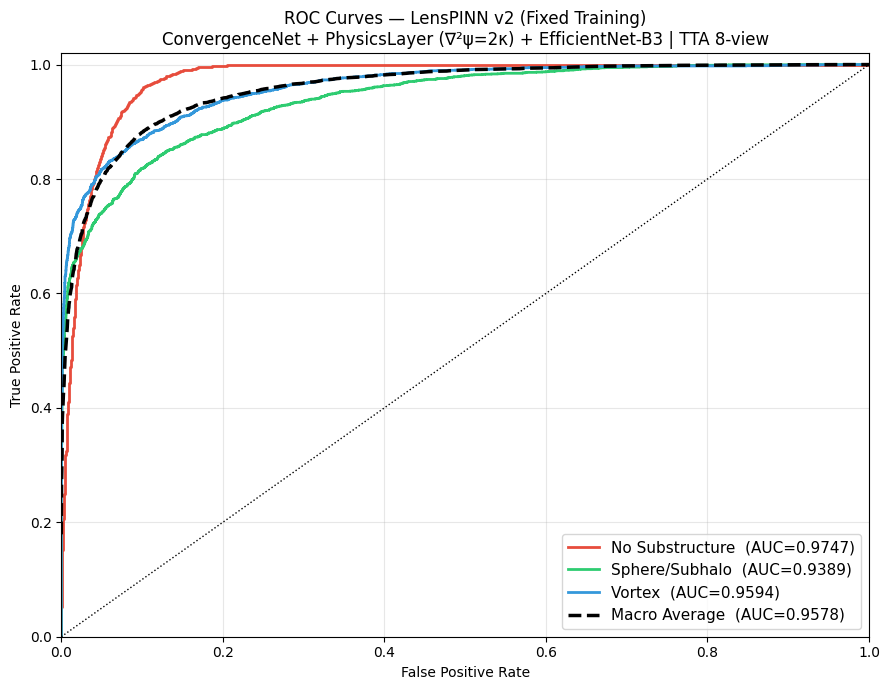


Per-class AUC:
         No Substructure: 0.9747  (v1: 0.9648  Δ+0.0099)
          Sphere/Subhalo: 0.9389  (v1: 0.9202  Δ+0.0187)
                  Vortex: 0.9594  (v1: 0.9502  Δ+0.0092)
           Macro Average: 0.9578  (v1: 0.9452  Δ+0.0126)
    EfficientNet-B3 base: 0.9553  (target to beat)


In [13]:
n  = CONFIG['num_classes']
lb = label_binarize(val_labels, classes=list(range(n)))
colors = ['#e74c3c','#2ecc71','#3498db']

fig, ax = plt.subplots(figsize=(9,7))
aucs, fpr_list = [], []

for i in range(n):
    fpr, tpr, _ = roc_curve(lb[:,i], val_probs[:,i])
    a = auc(fpr,tpr); aucs.append(a); fpr_list.append(fpr)
    ax.plot(fpr, tpr, color=colors[i], lw=2,
            label=f"{CONFIG['display_names'][i]}  (AUC={a:.4f})")

all_fpr  = np.unique(np.concatenate(fpr_list))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n):
    fpr, tpr, _ = roc_curve(lb[:,i], val_probs[:,i])
    mean_tpr += np.interp(all_fpr, fpr, tpr)
mean_tpr /= n
macro_auc = auc(all_fpr, mean_tpr)

ax.plot(all_fpr, mean_tpr, 'k--', lw=2.5, label=f'Macro Average  (AUC={macro_auc:.4f})')
ax.plot([0,1],[0,1],'k:',lw=1)
ax.set(xlim=[0,1], ylim=[0,1.02],
       xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='ROC Curves — LensPINN v2 (Fixed Training)\n'
             'ConvergenceNet + PhysicsLayer (∇²ψ=2κ) + EfficientNet-B3 | TTA 8-view')
ax.legend(loc='lower right', fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_pinn_v2.png', dpi=150)
plt.show()

print('\nPer-class AUC:')
baseline_per_class = {'No Substructure': 0.9648, 'Sphere/Subhalo': 0.9202, 'Vortex': 0.9502}
for name, a in zip(CONFIG['display_names'], aucs):
    delta = a - baseline_per_class[name]
    print(f'  {name:>22}: {a:.4f}  (v1: {baseline_per_class[name]:.4f}  Δ{delta:+.4f})')
print(f'  {"Macro Average":>22}: {macro_auc:.4f}  (v1: 0.9452  Δ{macro_auc-0.9452:+.4f})')
print(f'  {"EfficientNet-B3 base":>22}: 0.9553  (target to beat)')

## 10. Physics Loss Schedule Visualisation

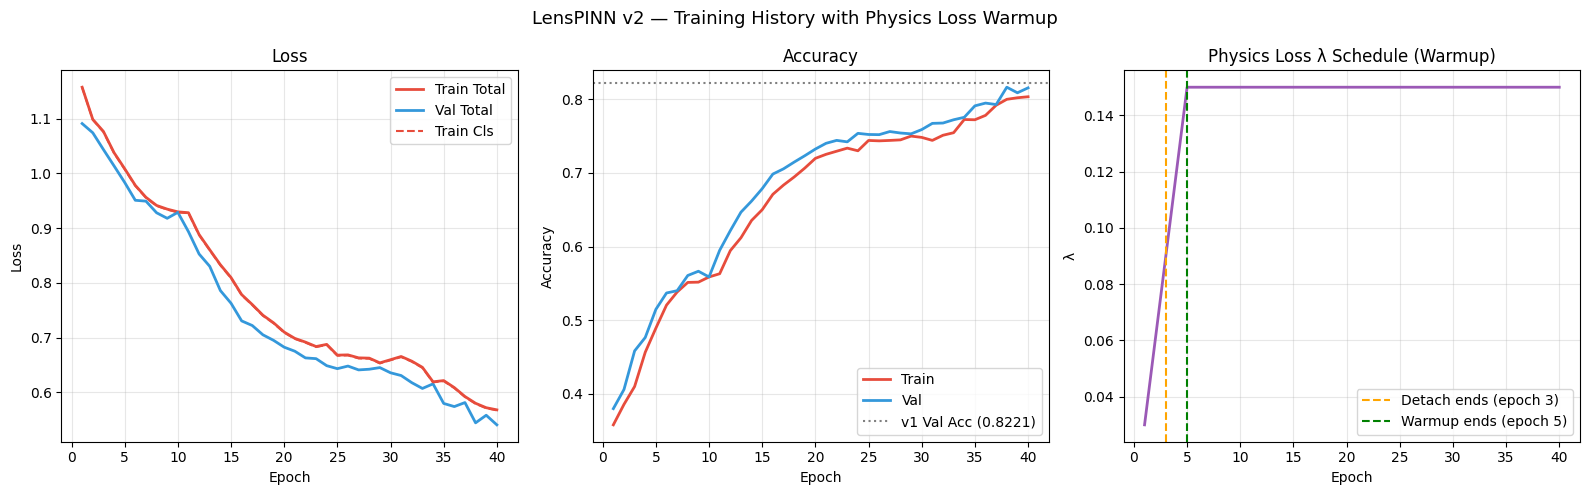


  LensPINN v2 — Final Results
  Macro AUC  : 0.9578  (v1: 0.9452  |  EfficientNet-B3: 0.9553)
  Val Acc    : 0.8464  (v1: 0.8221  |  EfficientNet-B3: 0.8484)


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ep = range(1, len(history['tr_loss'])+1)

axes[0].plot(ep, history['tr_loss'], label='Train Total', color='#e74c3c', lw=2)
axes[0].plot(ep, history['va_loss'], label='Val Total',   color='#3498db', lw=2)
axes[0].plot(ep, history['cls_loss'], label='Train Cls', color='#e74c3c', lw=1.5, ls='--')
axes[0].set(title='Loss', xlabel='Epoch', ylabel='Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['tr_acc'], label='Train', color='#e74c3c', lw=2)
axes[1].plot(ep, history['va_acc'], label='Val',   color='#3498db', lw=2)
axes[1].axhline(0.8221, color='gray', ls=':', lw=1.5, label='v1 Val Acc (0.8221)')
axes[1].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, history['lambda'], color='#9b59b6', lw=2)
axes[2].set(title='Physics Loss λ Schedule (Warmup)', xlabel='Epoch', ylabel='λ')
axes[2].axvline(CONFIG['phys_detach_epochs'], color='orange', ls='--',
                label=f'Detach ends (epoch {CONFIG["phys_detach_epochs"]})')
axes[2].axvline(CONFIG['lambda_warmup_epochs'], color='green', ls='--',
                label=f'Warmup ends (epoch {CONFIG["lambda_warmup_epochs"]})')
axes[2].legend(); axes[2].grid(alpha=0.3)

fig.suptitle('LensPINN v2 — Training History with Physics Loss Warmup', fontsize=13)
plt.tight_layout()
plt.savefig('training_history_pinn_v2.png', dpi=150)
plt.show()

print(f'\n{"="*60}')
print(f'  LensPINN v2 — Final Results')
print(f'  Macro AUC  : {macro_auc:.4f}  (v1: 0.9452  |  EfficientNet-B3: 0.9553)')
print(f'  Val Acc    : {val_acc:.4f}  (v1: 0.8221  |  EfficientNet-B3: 0.8484)')
print(f'{"="*60}')

## 11. Visualise Physics Maps (Qualitative)

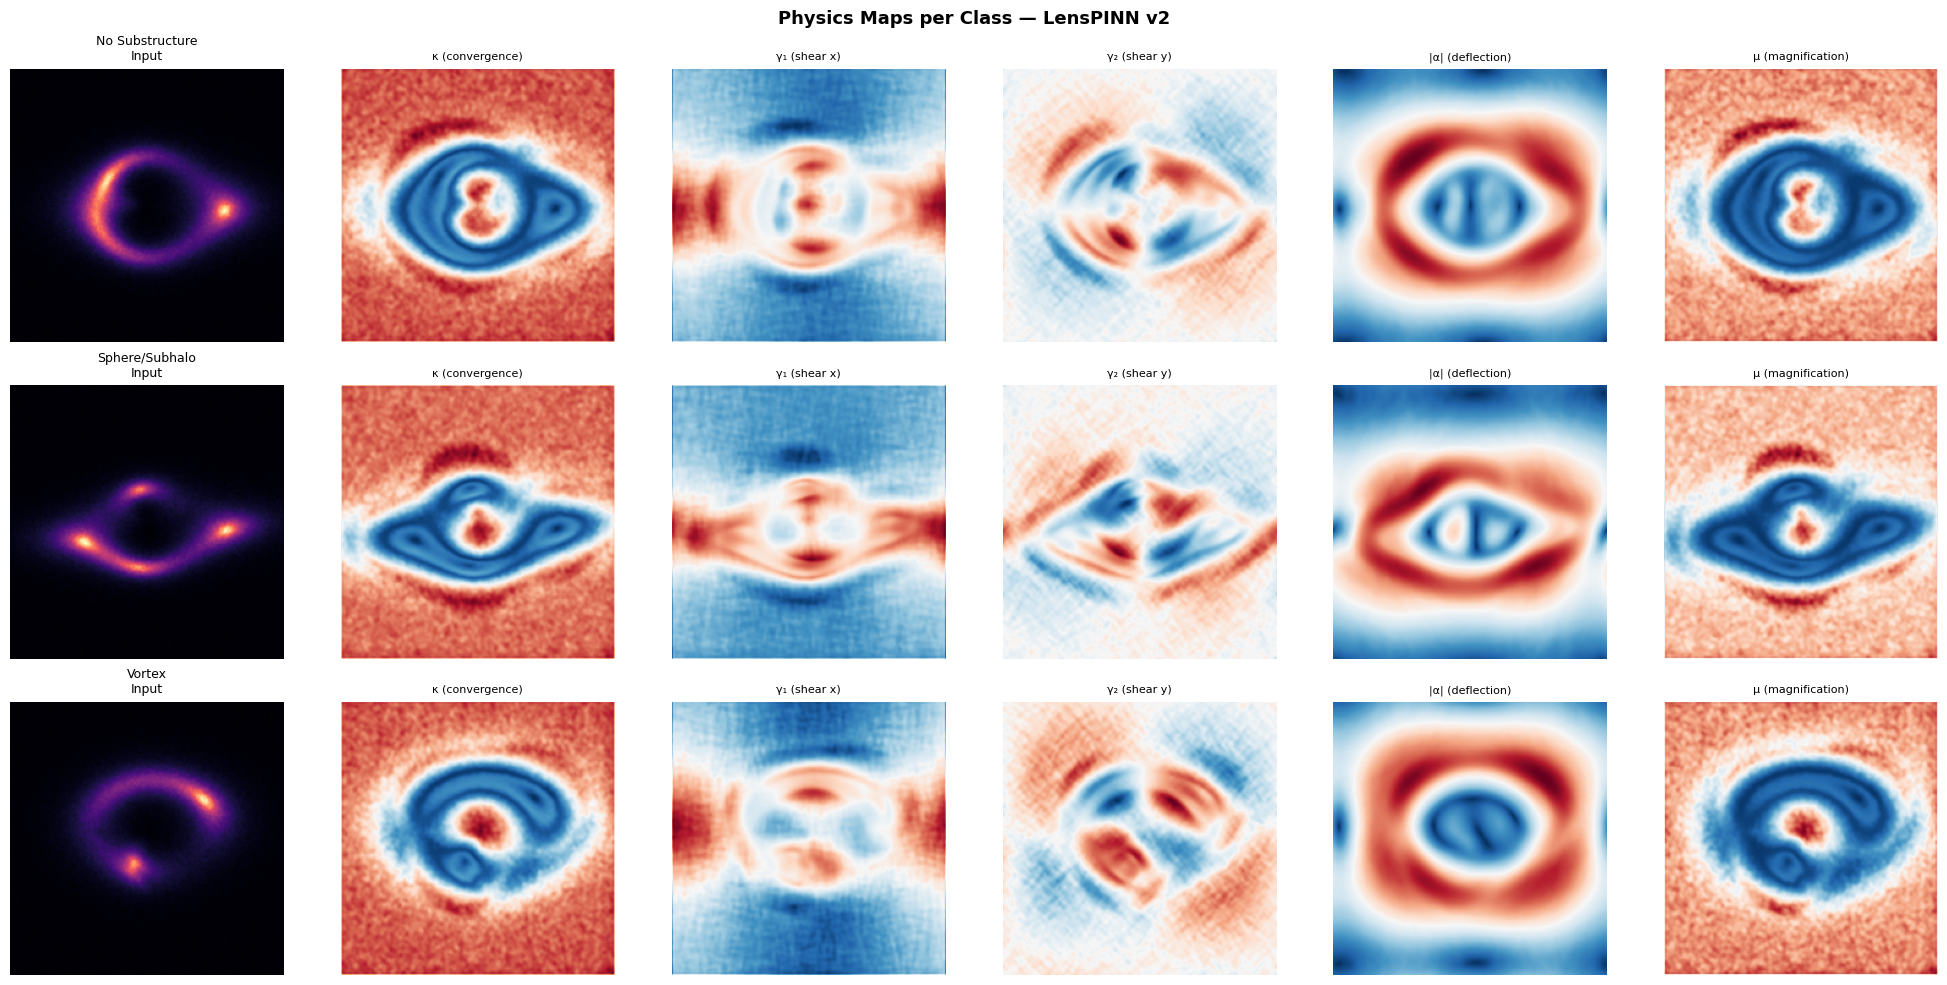

In [15]:
model.eval()
# Load one sample per class for visualisation
samples_per_class = {}
for i, cls in enumerate(CONFIG['class_names']):
    fps = [f for f,l in zip(val_fps, val_labs) if l == i][:1]
    ds  = LensDataset(fps, [i], CONFIG['img_size'], augment=False)
    img_n, img_r, _ = ds[0]
    samples_per_class[cls] = (img_n.unsqueeze(0).to(DEVICE), img_r.unsqueeze(0).to(DEVICE))

map_names = ['κ (convergence)', 'γ₁ (shear x)', 'γ₂ (shear y)', '|α| (deflection)', 'μ (magnification)']

fig, axes = plt.subplots(3, 6, figsize=(20, 10))
for row, (cls, disp) in enumerate(zip(CONFIG['class_names'], CONFIG['display_names'])):
    img_n, img_r = samples_per_class[cls]
    with torch.no_grad():
        kappa = model.convergence_net(img_r)
        phys_maps, source_recon = model.physics_layer(kappa, img_r)

    # Original image
    raw = img_r[0].cpu().permute(1,2,0).numpy()
    axes[row,0].imshow(raw[:,:,0], cmap='magma')
    axes[row,0].set_title(f'{disp}\nInput', fontsize=9)
    axes[row,0].axis('off')

    # Physics maps
    for col, name in enumerate(map_names):
        pm = phys_maps[0, col].cpu().numpy()
        axes[row, col+1].imshow(pm, cmap='RdBu_r')
        axes[row, col+1].set_title(name, fontsize=8)
        axes[row, col+1].axis('off')

fig.suptitle('Physics Maps per Class — LensPINN v2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('physics_maps_v2.png', dpi=150)
plt.show()